# Recitation Notebook: Linear Regression, Polynomial Regression, Ridge, and Lasso

## Goal

This notebook develops and compares several regression methods, starting from basic linear regression and extending to polynomial models and regularization. The main goals are:

1. Solve **linear regression** using the **closed-form pseudo-inverse solution**
2. Solve **linear regression** using **gradient descent**
3. Solve **linear regression** using **scikit-learn**
4. Compare the methods in terms of:
   - learned weights
   - training and test errors
   - runtime
   - fitted curves / lines
5. Extend the model to **polynomial regression**
6. Study **underfitting** and **overfitting** by varying polynomial degree
7. Introduce **Ridge** and **Lasso** regularization
8. Apply the same ideas to a **real-world regression dataset**

---

## Learning Objectives

By the end of this notebook, students should be able to:

- formulate linear regression in matrix form
- derive the least-squares objective function
- obtain the closed-form solution using the pseudo-inverse
- implement gradient descent for regression
- use scikit-learn to fit and evaluate regression models
- compare regression methods using weights, error metrics, plots, and runtime
- construct polynomial features and use them in regression
- explain the difference between underfitting and overfitting
- understand the role of regularization in controlling model complexity
- distinguish between Ridge and Lasso regression
- apply regression workflows to a real dataset

---

## Notebook Roadmap

The notebook is organized as follows:

1. **Setup and Imports**  
2. **Synthetic Data Generation**  
3. **Linear Regression Formulation**  
4. **Closed-Form Solution via Pseudo-Inverse**  
5. **Gradient Descent for Linear Regression**  
6. **Linear Regression with scikit-learn**  
7. **Comparison of Methods**  
   - weights  
   - error metrics  
   - runtime  
   - fitted plots  
8. **Polynomial Regression**  
9. **Underfitting and Overfitting**  
10. **Ridge and Lasso Regularization**  
11. **Real-World Regression Example**  
12. **Final Summary and Discussion Questions**

## 1. Setup and Imports

In this section, we import the libraries needed for numerical computation, plotting, data handling, timing, model construction, and evaluation.

### Required Libraries

- `numpy` for numerical operations and linear algebra
- `matplotlib.pyplot` for visualization
- `pandas` for organizing results in tables
- `time` for measuring runtime
- `sklearn.linear_model` for `LinearRegression`, `Ridge`, and `Lasso`
- `sklearn.preprocessing` for `PolynomialFeatures` and, if needed, `StandardScaler`
- `sklearn.model_selection` for train/test splitting
- `sklearn.metrics` for regression error metrics



In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

### Global Settings

In [133]:
RANDOM_STATE = 21
TEST_SIZE = 0.2

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 11

## 2. Synthetic Data Generation

We begin with a **simple synthetic dataset** so that the regression behavior can be visualized clearly.

### Plan

- Generate one-dimensional input points \(x\)
- Create target values \(y\) from a known function
- Add Gaussian noise

### Example Function for Linear Regression

$$
y = w_0 + w_1 x + \varepsilon
$$

### Example Function for Polynomial Regression

$$
y = \sin(2\pi x) + \varepsilon
$$

This gives a nonlinear target function that is useful for demonstrating polynomial fitting, underfitting, and overfitting.

### What to Record

For each experiment, record:

- number of points
- learned weights
- training error
- test error
- runtime
- plots of the data and model predictions

In [134]:
def make_linear_data(n_samples, noise_std=0.1, w0=1.0, w1=2.0, x_range=(0, 1), random_state=None):
    """
    Generate 1D synthetic linear-regression data:
        y = w0 + w1*x + noise
    """
    rng = np.random.default_rng(random_state)

    x = np.linspace(x_range[0], x_range[1], n_samples)
    noise = rng.normal(loc=0.0, scale=noise_std, size=n_samples)
    y = w0 + w1 * x + noise

    return x.reshape(-1, 1), y

In [135]:
def make_nonlinear_data(n_samples, noise_std=0.1, x_range=(0, 1), random_state=None):
    """
    Generate 1D synthetic nonlinear data for polynomial regression:
        y = sin(2*pi*x) + noise
    """
    rng = np.random.default_rng(random_state)

    x = np.linspace(x_range[0], x_range[1], n_samples)
    noise = rng.normal(loc=0.0, scale=noise_std, size=n_samples)
    y = np.sin(2 * np.pi * x) + noise

    return x.reshape(-1, 1), y

### 2.1. Create a synthetic linear dataset

In [136]:
X, y = make_linear_data(
    n_samples=20,
    noise_std=0.3,
    w0=1.0,
    w1=2.0,
    x_range=(0, 1),
    random_state=RANDOM_STATE
)

### 2.2. Plot the generated dataset

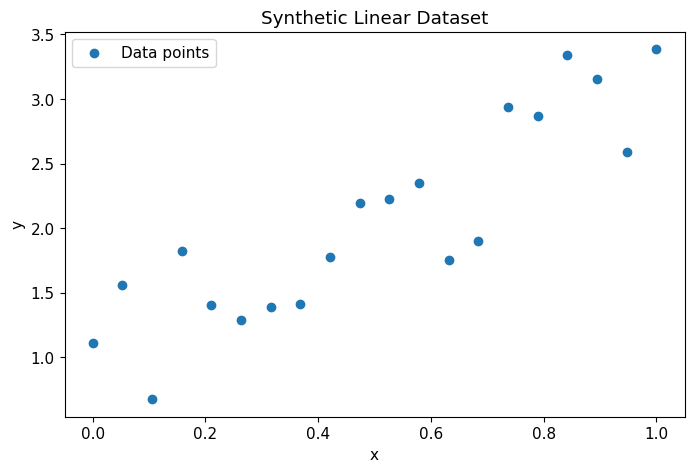

In [137]:
plt.figure()
plt.scatter(X, y, label="Data points")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Synthetic Linear Dataset")
plt.legend()
plt.show()

### 2.3. Split into training and test sets

In [138]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

### 2.4. Build design matrices

In [139]:
def add_bias_column(X):
    """
    Add a column of ones to the input matrix X.
    If X has shape (N, 1), output has shape (N, 2).
    """
    return np.c_[np.ones((X.shape[0], 1)), X]

In [140]:
X_train_design = add_bias_column(X_train)
X_test_design = add_bias_column(X_test)

## 3. Linear Regression Formulation

We begin with the linear regression hypothesis:

$$
\hat{y} = Xw
$$

The objective of least-squares linear regression is to find the parameter vector $(w)$ that minimizes the prediction error.

### Least-Squares Objective Function

$$
J(w) = \frac{1}{N}\|Xw - y\|_2^2
$$

Equivalently, this can be written as:

$$
J(w) = \frac{1}{N}(Xw - y)^T(Xw - y)
$$

This objective measures the average squared difference between the predicted values and the true target values.

### Adding the Bias Term

To include the intercept term in the parameter vector, we augment the input matrix with a column of ones:

$$
X =
\begin{bmatrix}
1 & x_1 \\
1 & x_2 \\
\vdots & \vdots \\
1 & x_N
\end{bmatrix}
$$

Then the model becomes:

$$
\hat{y}_i = w_0 + w_1 x_i
$$

## 4. Direct Solution via the Pseudo-Inverse

A closed-form solution for linear regression can be obtained by minimizing the least-squares objective directly.

Starting from

$$
J(w) = \frac{1}{N}\|Xw - y\|_2^2
$$

we compute the gradient with respect to \(w\) and set it equal to zero:

$$
\nabla_w J(w) = \frac{2}{N} X^T (Xw - y) = 0
$$

This gives the **normal equation**:

$$
X^T X w = X^T y
$$

If the matrix $(X^T X)$ is invertible, the solution is:

$$
w = (X^T X)^{-1} X^T y
$$

### 4.1. Fit using pseudo-inverse and measure runtim

In [141]:
start_time = time.time()

w_direct = np.linalg.pinv(X_train_design) @ y_train

runtime_direct = time.time() - start_time

### 4.2. Predictions

In [142]:
y_train_pred_direct = X_train_design @ w_direct
y_test_pred_direct = X_test_design @ w_direct

### 4.3. Error metrics

In [143]:
train_mse_direct = mean_squared_error(y_train, y_train_pred_direct)
test_mse_direct = mean_squared_error(y_test, y_test_pred_direct)

train_rmse_direct = np.sqrt(train_mse_direct)
test_rmse_direct = np.sqrt(test_mse_direct)

train_mae_direct = mean_absolute_error(y_train, y_train_pred_direct)
test_mae_direct = mean_absolute_error(y_test, y_test_pred_direct)

train_r2_direct = r2_score(y_train, y_train_pred_direct)
test_r2_direct = r2_score(y_test, y_test_pred_direct)

### 4.4. Print results

In [144]:
print("Direct solution via pseudo-inverse")
print("-" * 40)
print(f"Learned weights: w0 = {w_direct[0]:.6f}, w1 = {w_direct[1]:.6f}")
print(f"Train MSE  : {train_mse_direct:.6f}")
print(f"Test MSE   : {test_mse_direct:.6f}")
print(f"Train RMSE : {train_rmse_direct:.6f}")
print(f"Test RMSE  : {test_rmse_direct:.6f}")
print(f"Train MAE  : {train_mae_direct:.6f}")
print(f"Test MAE   : {test_mae_direct:.6f}")
print(f"Train R^2  : {train_r2_direct:.6f}")
print(f"Test R^2   : {test_r2_direct:.6f}")
print(f"Runtime    : {runtime_direct:.6e} seconds")

Direct solution via pseudo-inverse
----------------------------------------
Learned weights: w0 = 0.991531, w1 = 2.202782
Train MSE  : 0.125971
Test MSE   : 0.139334
Train RMSE : 0.354924
Test RMSE  : 0.373275
Train MAE  : 0.305194
Test MAE   : 0.315220
Train R^2  : 0.785288
Test R^2   : 0.736522
Runtime    : 4.565716e-04 seconds


### 4.5. Plot fitted line on the training range

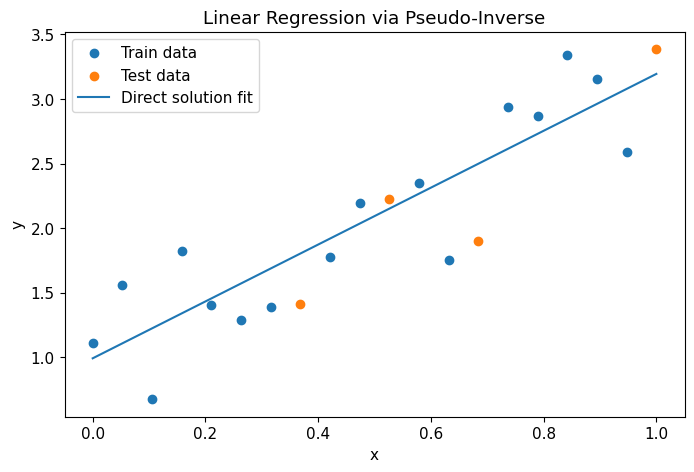

In [145]:
x_line = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
x_line_design = add_bias_column(x_line)
y_line_direct = x_line_design @ w_direct

plt.figure()
plt.scatter(X_train, y_train, label="Train data")
plt.scatter(X_test, y_test, label="Test data")
plt.plot(x_line, y_line_direct, label="Direct solution fit")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear Regression via Pseudo-Inverse")
plt.legend()
plt.show()

## 5. Gradient Descent Solution

Instead of solving the least-squares problem analytically, we can minimize the objective function iteratively using **gradient descent**.

Starting from the same loss function,

$$
J(w) = \frac{1}{N}\|Xw - y\|_2^2
$$

the gradient with respect to the parameter vector \(w\) is:

$$
\nabla_w J(w) = \frac{2}{N} X^T (Xw - y)
$$

Gradient descent updates the parameters by moving in the direction opposite to the gradient:

$$
w^{(t+1)} = w^{(t)} - \eta \, \nabla_w J\!\left(w^{(t)}\right)
$$

where:

- $(\eta)$ is the **learning rate**
- $(t)$ is the **iteration index**

Substituting the gradient expression into the update rule gives:

$$
w^{(t+1)} = w^{(t)} - \eta \frac{2}{N} X^T \left(Xw^{(t)} - y\right)
$$

### Important Teaching Points

- **Effect of the learning rate**: the value of \(\eta\) strongly affects convergence
- **Too small $(\eta)$**: convergence is very slow
- **Too large $(\eta)$**: the algorithm may oscillate or diverge
- **Initialization**: the starting value of $(w)$ can affect the speed of convergence
- **Stopping criterion**: the algorithm must stop after a fixed number of iterations or when the loss stops changing significantly

### Why Gradient Descent?

Gradient descent is useful when a closed-form solution is expensive, inconvenient, or numerically less attractive. It is especially important in machine learning because many models cannot be solved analytically and must be trained iteratively.

In [146]:
def gradient_descent(X, y, lr, n_iter, w_init=None):
    """
    Batch gradient descent for linear regression.

    Parameters
    ----------
    X : np.ndarray of shape (N, d)
        Design matrix, including bias column if needed.
    y : np.ndarray of shape (N,)
        Target vector.
    lr : float
        Learning rate.
    n_iter : int
        Number of iterations.
    w_init : np.ndarray of shape (d,), optional
        Initial weights. If None, initialized to zeros.

    Returns
    -------
    w : np.ndarray of shape (d,)
        Final learned weights.
    cost_history : np.ndarray of shape (n_iter,)
        Cost value at each iteration.
    converged : bool
        Whether the optimization remained numerically stable.
    """
    n_samples, n_features = X.shape

    if w_init is None:
        w = np.zeros(n_features)
    else:
        w = w_init.copy()

    cost_history = []
    converged = True

    for _ in range(n_iter):
        # Predictions
        y_pred = X @ w

        # Gradient of J(w) = (1/N)||Xw - y||^2
        grad = (2 / n_samples) * (X.T @ (y_pred - y))

        # Update
        w = w - lr * grad

        # Cost
        cost = mean_squared_error(y, y_pred)
        cost_history.append(cost)

        # Basic divergence / instability check
        if not np.isfinite(cost):
            converged = False
            break

    return w, np.array(cost_history), converged

In [147]:
lr = 0.001
n_iter = 1000


### 5.1. Train with gradient descent

In [148]:
start_time = time.time()
w_gd, cost_history, converged = gradient_descent(
                X_train_design,
                y_train,
                lr=lr,
                n_iter=n_iter,
                w_init=None)

runtime_gd = time.time() - start_time

### 5.2.Predictions

In [149]:
y_train_pred_gd = X_train_design @ w_gd
y_test_pred_gd = X_test_design @ w_gd

### 5.3. Error metrics

In [150]:
train_mse_gd = mean_squared_error(y_train, y_train_pred_gd)
test_mse_gd = mean_squared_error(y_test, y_test_pred_gd)

train_rmse_gd = np.sqrt(train_mse_gd)
test_rmse_gd = np.sqrt(test_mse_gd)

train_mae_gd = mean_absolute_error(y_train, y_train_pred_gd)
test_mae_gd = mean_absolute_error(y_test, y_test_pred_gd)

train_r2_gd = r2_score(y_train, y_train_pred_gd)
test_r2_gd = r2_score(y_test, y_test_pred_gd)

### 5.4. Print results

In [151]:
print("Gradient Descent Solution")
print("-" * 40)
print(f"Learned weights: w0 = {w_gd[0]:.6f}, w1 = {w_gd[1]:.6f}")
print(f"Train MSE  : {train_mse_gd:.6f}")
print(f"Test MSE   : {test_mse_gd:.6f}")
print(f"Train RMSE : {train_rmse_gd:.6f}")
print(f"Test RMSE  : {test_rmse_gd:.6f}")
print(f"Train MAE  : {train_mae_gd:.6f}")
print(f"Test MAE   : {test_mae_gd:.6f}")
print(f"Train R^2  : {train_r2_gd:.6f}")
print(f"Test R^2   : {test_r2_gd:.6f}")
print(f"Runtime    : {runtime_gd:.6e} seconds")

Gradient Descent Solution
----------------------------------------
Learned weights: w0 = 1.435945, w1 = 0.964890
Train MSE  : 0.288304
Test MSE   : 0.308498
Train RMSE : 0.536940
Test RMSE  : 0.555426
Train MAE  : 0.446585
Test MAE   : 0.461812
Train R^2  : 0.508598
Test R^2   : 0.416635
Runtime    : 4.586232e-01 seconds


### 5.5. Cost versus iteration

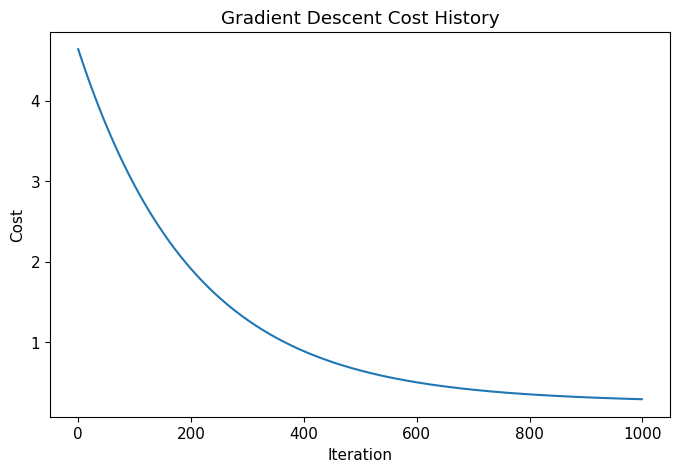

In [152]:
plt.figure()
plt.plot(cost_history)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Gradient Descent Cost History")
plt.show()

### 5.6. Plot fitted line on the training range

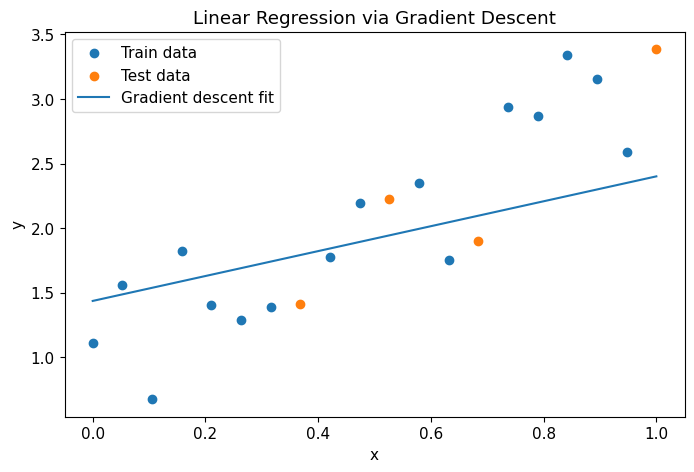

In [153]:
x_line = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
x_line_design = add_bias_column(x_line)
y_line_gd = x_line_design @ w_gd

plt.figure()
plt.scatter(X_train, y_train, label="Train data")
plt.scatter(X_test, y_test, label="Test data")
plt.plot(x_line, y_line_gd, label="Gradient descent fit")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear Regression via Gradient Descent")
plt.legend()
plt.show()

## 6. scikit-learn Linear Regression

In this section, we use `sklearn.linear_model.LinearRegression` as a reference implementation for ordinary least-squares linear regression.



### 6.1. Fit scikit-learn LinearRegression

In [154]:
start_time = time.time()

sk_model = LinearRegression()
sk_model.fit(X_train, y_train)

runtime_sklearn = time.time() - start_time

### 6.2. Predictions

In [155]:
y_train_pred_sklearn = sk_model.predict(X_train)
y_test_pred_sklearn = sk_model.predict(X_test)

### 6.3. Error metrics

In [156]:
train_mse_sklearn = mean_squared_error(y_train, y_train_pred_sklearn)
test_mse_sklearn = mean_squared_error(y_test, y_test_pred_sklearn)

train_rmse_sklearn = np.sqrt(train_mse_sklearn)
test_rmse_sklearn = np.sqrt(test_mse_sklearn)

train_mae_sklearn = mean_absolute_error(y_train, y_train_pred_sklearn)
test_mae_sklearn = mean_absolute_error(y_test, y_test_pred_sklearn)

train_r2_sklearn = r2_score(y_train, y_train_pred_sklearn)
test_r2_sklearn = r2_score(y_test, y_test_pred_sklearn)

### 6.4. Print results

In [157]:
print("scikit-learn LinearRegression")
print("-" * 40)
print(f"intercept_ = {sk_model.intercept_:.6f}")
print(f"coef_      = {sk_model.coef_[0]:.6f}")
print(f"Train MSE  = {train_mse_sklearn:.6f}")
print(f"Test MSE   = {test_mse_sklearn:.6f}")
print(f"Train RMSE = {train_rmse_sklearn:.6f}")
print(f"Test RMSE  = {test_rmse_sklearn:.6f}")
print(f"Train MAE  = {train_mae_sklearn:.6f}")
print(f"Test MAE   = {test_mae_sklearn:.6f}")
print(f"Train R²   = {train_r2_sklearn:.6f}")
print(f"Test R²    = {test_r2_sklearn:.6f}")
print(f"Runtime    = {runtime_sklearn:.6e} seconds")

scikit-learn LinearRegression
----------------------------------------
intercept_ = 0.991531
coef_      = 2.202782
Train MSE  = 0.125971
Test MSE   = 0.139334
Train RMSE = 0.354924
Test RMSE  = 0.373275
Train MAE  = 0.305194
Test MAE   = 0.315220
Train R²   = 0.785288
Test R²    = 0.736522
Runtime    = 2.776623e-03 seconds


### 6.5. Plot fitted line on the training range

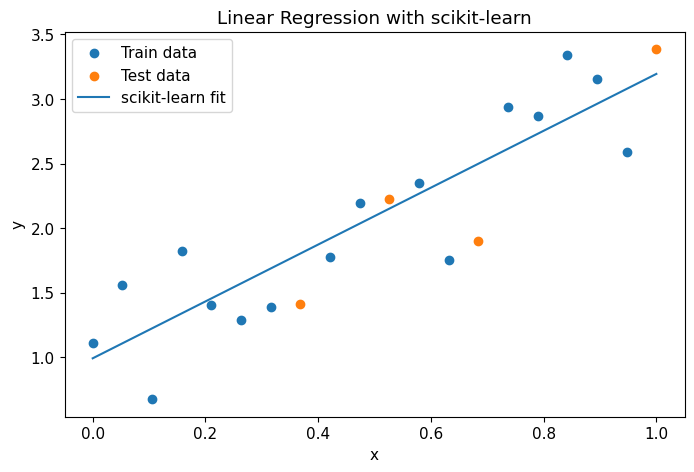

In [158]:
x_line = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
y_line_sklearn = sk_model.predict(x_line)

plt.figure()
plt.scatter(X_train, y_train, label="Train data")
plt.scatter(X_test, y_test, label="Test data")
plt.plot(x_line, y_line_sklearn, label="scikit-learn fit")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear Regression with scikit-learn")
plt.legend()
plt.show()

## 7. Linear regression comparison section


In [159]:
comparison_df = pd.DataFrame([
    {
        "method": "Pseudo-inverse",
        "intercept": w_direct[0],
        "coefficient": w_direct[1],
        "train_mse": train_mse_direct,
        "test_mse": test_mse_direct,
        "train_rmse": train_rmse_direct,
        "test_rmse": test_rmse_direct,
        "train_mae": train_mae_direct,
        "test_mae": test_mae_direct,
        "train_r2": train_r2_direct,
        "test_r2": test_r2_direct,
        "runtime_sec": runtime_direct
    },
    {
        "method": "Gradient Descent",
        "intercept": w_gd[0],
        "coefficient": w_gd[1],
        "train_mse": train_mse_gd,
        "test_mse": test_mse_gd,
        "train_rmse": train_rmse_gd,
        "test_rmse": test_rmse_gd,
        "train_mae": train_mae_gd,
        "test_mae": test_mae_gd,
        "train_r2": train_r2_gd,
        "test_r2": test_r2_gd,
        "runtime_sec": runtime_gd
    },
    {
        "method": "scikit-learn",
        "intercept": sk_model.intercept_,
        "coefficient": sk_model.coef_[0],
        "train_mse": train_mse_sklearn,
        "test_mse": test_mse_sklearn,
        "train_rmse": train_rmse_sklearn,
        "test_rmse": test_rmse_sklearn,
        "train_mae": train_mae_sklearn,
        "test_mae": test_mae_sklearn,
        "train_r2": train_r2_sklearn,
        "test_r2": test_r2_sklearn,
        "runtime_sec": runtime_sklearn
    }
])

comparison_df

,method,intercept,coefficient,train_mse,test_mse,train_rmse,test_rmse,train_mae,test_mae,train_r2,test_r2,runtime_sec
0,Pseudo-inverse,0.991531,2.202782,0.125971,0.139334,0.354924,0.373275,0.305194,0.315220,0.785288,0.736522,0.000457
1,Gradient Descent,1.435945,0.964890,0.288304,0.308498,0.536940,0.555426,0.446585,0.461812,0.508598,0.416635,0.458623
2,scikit-learn,0.991531,2.202782,0.125971,0.139334,0.354924,0.373275,0.305194,0.315220,0.785288,0.736522,0.002777


## 8. Plotting section for linear regression

### Plots
1. Scatter plot of training points
2. Ground-truth line (if synthetic)
3. Prediction line from pseudo-inverse
4. Prediction line from gradient descent
5. Prediction line from scikit-learn
6. Loss curve for gradient descent


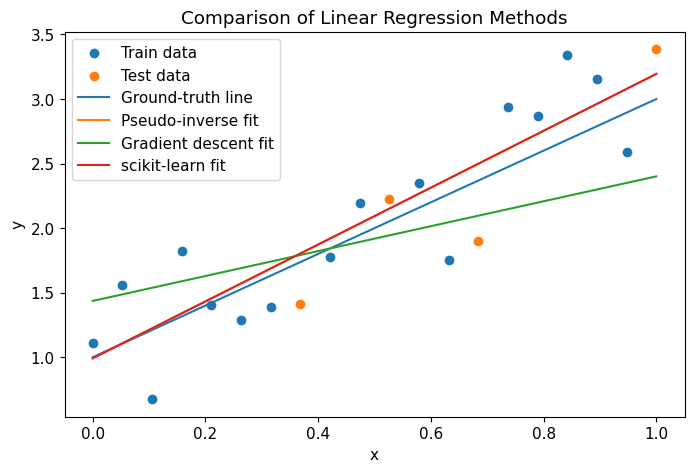

In [160]:
x_line = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
y_true_line = 1.0 + 2.0 * x_line   # uses the true generating parameters w0=1, w1=2

plt.figure()
plt.scatter(X_train, y_train, label="Train data")
plt.scatter(X_test, y_test, label="Test data")
plt.plot(x_line, y_true_line, label="Ground-truth line")
plt.plot(x_line, y_line_direct, label="Pseudo-inverse fit")
plt.plot(x_line, y_line_gd, label="Gradient descent fit")
plt.plot(x_line, y_line_sklearn, label="scikit-learn fit")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Comparison of Linear Regression Methods")
plt.legend()
plt.show()

## 9. Transition to Polynomial Regression

Linear regression can be extended to model nonlinear relationships by transforming the input features.

For a polynomial model of degree \(p\), the prediction is written as

$$
\hat{y} = w_0 + w_1 x + w_2 x^2 + \cdots + w_p x^p
$$

Although this expression is nonlinear in the input variable \(x\), it is still **linear in the parameters** $(w_0, w_1, \dots, w_p)$.  
For this reason, polynomial regression is still a form of linear regression.

### Matrix View

If we define the polynomial feature vector as

$$
\phi(x) = [1,\; x,\; x^2,\; \dots,\; x^p]^T
$$

then the model can be written compactly as

$$
\hat{y} = w^T \phi(x)
$$

where $(w = [w_0, w_1, \dots, w_p]^T)$.

### Main Idea

Instead of changing the regression algorithm itself, we change the **representation of the input**.  
Once polynomial features are created, the same regression methods can still be used:

- pseudo-inverse
- gradient descent
- scikit-learn linear regression

### Implementation Note

In the notebook, we will use `sklearn.preprocessing.PolynomialFeatures` to generate the polynomial feature matrix automatically.

### 9.1. Create a synthetic linear dataset

In [161]:
X, y = make_nonlinear_data(
    n_samples=20,
    noise_std=0.3,
    x_range=(0, 1),
    random_state=RANDOM_STATE
)

### 9.2. Plot the generated dataset

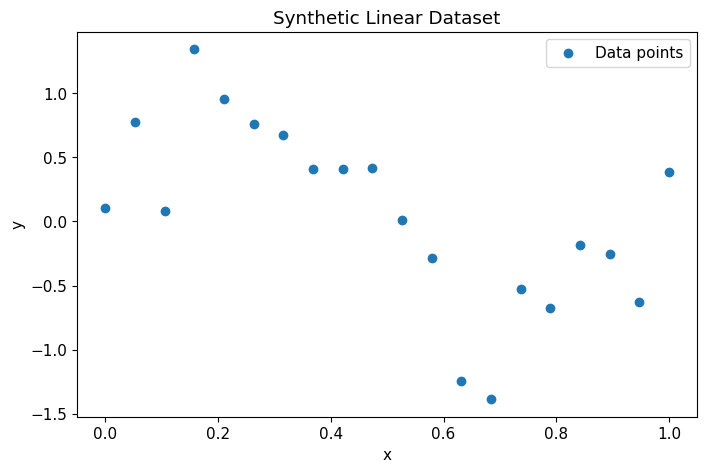

In [162]:
plt.figure()
plt.scatter(X, y, label="Data points")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Synthetic Linear Dataset")
plt.legend()
plt.show()

### 9.3. Split into training and test sets

In [163]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

## 10. Polynomial regression


In [164]:
degrees = [1, 3, 11]
poly_results = []

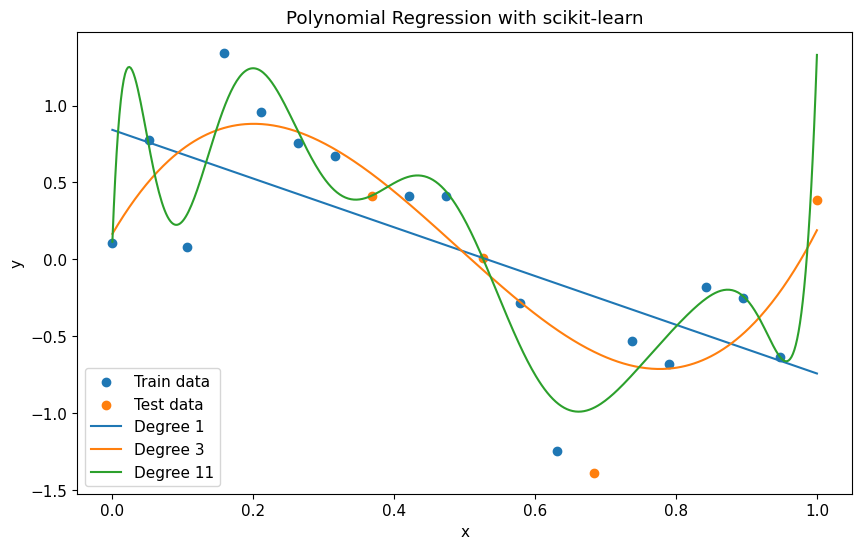

In [165]:
# Train/test split on the nonlinear dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

# Smooth x-grid for plotting fitted curves
x_plot = np.linspace(X.min(), X.max(), 500).reshape(-1, 1)

plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, label="Train data")
plt.scatter(X_test, y_test, label="Test data")

for degree in degrees:
    # Create polynomial features
    poly = PolynomialFeatures(degree=degree, include_bias=True)

    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    x_plot_poly = poly.transform(x_plot)

    # Fit linear regression on polynomial features
    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    # Predictions
    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)
    y_plot = model.predict(x_plot_poly)

    # Metrics
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    train_rmse = np.sqrt(train_mse)
    test_rmse = np.sqrt(test_mse)
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    # Store results
    poly_results.append({
        "degree": degree,
        "train_mse": train_mse,
        "test_mse": test_mse,
        "train_rmse": train_rmse,
        "test_rmse": test_rmse,
        "train_r2": train_r2,
        "test_r2": test_r2,
        "intercept": model.intercept_,
        "n_coefficients": len(model.coef_)
    })

    # Plot fitted curve
    plt.plot(x_plot, y_plot, label=f"Degree {degree}")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Polynomial Regression with scikit-learn")
plt.legend()
plt.show()

In [166]:
# Comparison table
poly_results_df = pd.DataFrame(poly_results)
poly_results_df.round(6)

,degree,train_mse,test_mse,train_rmse,test_rmse,train_r2,test_r2,intercept,n_coefficients
0,1,0.223700,0.651545,0.472970,0.807183,0.515636,-0.207987,0.841663,2
1,3,0.120157,0.170431,0.346637,0.412833,0.739832,0.684015,0.165863,4
2,11,0.037249,0.267427,0.193000,0.517133,0.919347,0.504182,0.114561,12


## 12. Ridge Regularization

Ridge regression extends linear regression by adding an \$(L_2)$ penalty on the model weights. This penalty discourages large coefficients and helps control model complexity.

The Ridge objective function is

$$
J(w) = \frac{1}{N}\|Xw - y\|_2^2 + \lambda \|w\|_2^2
$$

where:

- $(\frac{1}{N}\|Xw - y\|_2^2)$ is the data-fitting term
- $(\lambda \|w\|_2^2)$ is the regularization term
- $(\lambda \ge 0)$ controls the strength of regularization

### Interpretation

Ridge regularization:

- reduces variance
- improves numerical stability
- helps control overfitting
- shrinks the coefficients smoothly toward zero

As \$(\lambda)$ increases, the model becomes more constrained, and the fitted curve usually becomes less flexible.

### Closed-Form Solution

For Ridge regression, the regularized normal-equation solution is

$$
w = (X^T X + \lambda I)^{-1} X^T y
$$

where \$(I)$ is the identity matrix.

## 13. Lasso Regularization

Lasso regression adds an \$(L_1)$ penalty to the regression objective.  
This penalty encourages sparsity in the learned coefficients, which means that some coefficients can become exactly zero.

The Lasso objective function is

$$
J(w) = \frac{1}{N}\|Xw - y\|_2^2 + \lambda \|w\|_1
$$

where

$$
\|w\|_1 = \sum_j |w_j|
$$

and \$(\lambda \ge 0)$ controls the strength of regularization.

### Interpretation

Lasso regularization:

- can drive some coefficients exactly to zero
- performs implicit feature selection
- is useful when many polynomial terms are unnecessary

As \$(\lambda)$ increases, more coefficients may be shrunk to zero, leading to a simpler and more interpretable model.

### Discussion Points

- **Ridge** shrinks coefficients continuously toward zero
- **Lasso** can produce sparse models by setting some coefficients exactly to zero
- the optimization problem for Lasso does not have the same simple closed-form solution as ordinary least squares or Ridge

## 14. Ridge and Lasso comparison

This section should compare:
- unregularized polynomial regression,
- Ridge,
- Lasso.


In [185]:
degree = 5

poly = PolynomialFeatures(degree=degree, include_bias=False)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

x_plot = np.linspace(X.min(), X.max(), 500).reshape(-1, 1)
x_plot_poly = poly.transform(x_plot)

### 14.1. Feature scaling

In [186]:
scaler = StandardScaler()
X_train_poly_scaled = scaler.fit_transform(X_train_poly)
X_test_poly_scaled = scaler.transform(X_test_poly)
x_plot_poly_scaled = scaler.transform(x_plot_poly)

### 14.2. Fit polynomial regression, Ridge, and Lasso

In [196]:
# Ordinary polynomial regression
model_linear = LinearRegression()
model_linear.fit(X_train_poly_scaled, y_train)

# Ridge regression
model_ridge = Ridge(alpha=0.01)
model_ridge.fit(X_train_poly_scaled, y_train)

# Lasso regression
model_lasso = Lasso(alpha=0.01, max_iter=100000)
model_lasso.fit(X_train_poly_scaled, y_train)

# Predictions
y_train_pred_linear = model_linear.predict(X_train_poly_scaled)
y_test_pred_linear = model_linear.predict(X_test_poly_scaled)
y_plot_linear = model_linear.predict(x_plot_poly_scaled)

y_train_pred_ridge = model_ridge.predict(X_train_poly_scaled)
y_test_pred_ridge = model_ridge.predict(X_test_poly_scaled)
y_plot_ridge = model_ridge.predict(x_plot_poly_scaled)

y_train_pred_lasso = model_lasso.predict(X_train_poly_scaled)
y_test_pred_lasso = model_lasso.predict(X_test_poly_scaled)
y_plot_lasso = model_lasso.predict(x_plot_poly_scaled)

### 14.3. Compare errors

In [197]:
ridge_lasso_df = pd.DataFrame([
    {
        "model": "Polynomial (no regularization)",
        "train_mse": mean_squared_error(y_train, y_train_pred_linear),
        "test_mse": mean_squared_error(y_test, y_test_pred_linear),
        "train_r2": r2_score(y_train, y_train_pred_linear),
        "test_r2": r2_score(y_test, y_test_pred_linear),
        "nonzero_coefficients": np.sum(np.abs(model_linear.coef_) > 1e-10)
    },
    {
        "model": "Ridge",
        "train_mse": mean_squared_error(y_train, y_train_pred_ridge),
        "test_mse": mean_squared_error(y_test, y_test_pred_ridge),
        "train_r2": r2_score(y_train, y_train_pred_ridge),
        "test_r2": r2_score(y_test, y_test_pred_ridge),
        "nonzero_coefficients": np.sum(np.abs(model_ridge.coef_) > 1e-10)
    },
    {
        "model": "Lasso",
        "train_mse": mean_squared_error(y_train, y_train_pred_lasso),
        "test_mse": mean_squared_error(y_test, y_test_pred_lasso),
        "train_r2": r2_score(y_train, y_train_pred_lasso),
        "test_r2": r2_score(y_test, y_test_pred_lasso),
        "nonzero_coefficients": np.sum(np.abs(model_lasso.coef_) > 1e-10)
    }
])

ridge_lasso_df.round(6)



,model,train_mse,test_mse,train_r2,test_r2,nonzero_coefficients
0,Polynomial (no regularization),0.089194,0.830228,0.806874,-0.539273,5
1,Ridge,0.130515,0.189573,0.717404,0.648525,5
2,Lasso,0.179235,0.371131,0.611914,0.311911,2


### 14.4. Plot model fits

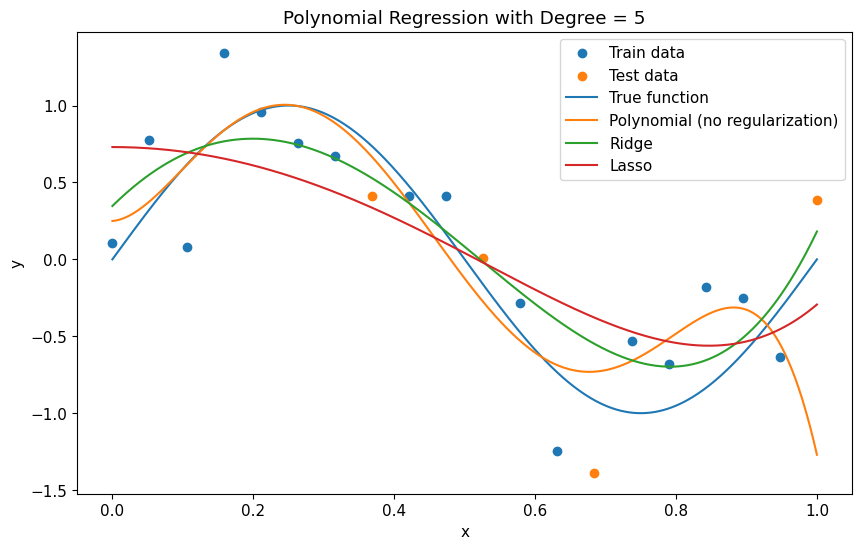

In [199]:
plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, label="Train data")
plt.scatter(X_test, y_test, label="Test data")

y_true = np.sin(2 * np.pi * x_plot)
plt.plot(x_plot, y_true, label="True function")

plt.plot(x_plot, y_plot_linear, label="Polynomial (no regularization)")
plt.plot(x_plot, y_plot_ridge, label="Ridge")
plt.plot(x_plot, y_plot_lasso, label="Lasso")

plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Polynomial Regression with Degree = {degree}")
plt.legend()
plt.show()

## 15. Real-world application

Use a simple real-world regression dataset.

Good option:
- `sklearn.datasets.load_diabetes`


In [259]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing(as_frame=True)
df = housing.frame.copy()

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


### 15.1. Real-world dataset:

In [278]:
X = df.drop(columns=["MedHouseVal"]).values
y = df["MedHouseVal"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)

X_train shape: (16512, 8)
X_test shape : (4128, 8)


### 15.2. Linear, Linear + Ridge

In [289]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

ridge_linear_model = Ridge(alpha=1)
ridge_linear_model.fit(X_train, y_train)

y_train_pred_linear = linear_model.predict(X_train)
y_test_pred_linear = linear_model.predict(X_test)

y_train_pred_ridge_linear = ridge_linear_model.predict(X_train)
y_test_pred_ridge_linear = ridge_linear_model.predict(X_test)

### 15.3. Poly3, Poly3 + Ridge

In [294]:
poly = PolynomialFeatures(degree=3, include_bias=False)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

scaler = StandardScaler()
X_train_poly_scaled = scaler.fit_transform(X_train_poly)
X_test_poly_scaled = scaler.transform(X_test_poly)

poly3_model = LinearRegression()
poly3_model.fit(X_train_poly_scaled, y_train)

ridge_poly3_model = Ridge(alpha=1)
ridge_poly3_model.fit(X_train_poly_scaled, y_train)

y_train_pred_poly3 = poly3_model.predict(X_train_poly_scaled)
y_test_pred_poly3 = poly3_model.predict(X_test_poly_scaled)

y_train_pred_ridge_poly3 = ridge_poly3_model.predict(X_train_poly_scaled)
y_test_pred_ridge_poly3 = ridge_poly3_model.predict(X_test_poly_scaled)

### 15.4. Comparision table

In [295]:
real_world_comparison_df = pd.DataFrame([
    {
        "model": "Linear",
        "train_mse": mean_squared_error(y_train, y_train_pred_linear),
        "test_mse": mean_squared_error(y_test, y_test_pred_linear),
        "train_rmse": np.sqrt(mean_squared_error(y_train, y_train_pred_linear)),
        "test_rmse": np.sqrt(mean_squared_error(y_test, y_test_pred_linear)),
        "train_mae": mean_absolute_error(y_train, y_train_pred_linear),
        "test_mae": mean_absolute_error(y_test, y_test_pred_linear),
        "train_r2": r2_score(y_train, y_train_pred_linear),
        "test_r2": r2_score(y_test, y_test_pred_linear),
    },
    {
        "model": "Linear + Ridge",
        "train_mse": mean_squared_error(y_train, y_train_pred_ridge_linear),
        "test_mse": mean_squared_error(y_test, y_test_pred_ridge_linear),
        "train_rmse": np.sqrt(mean_squared_error(y_train, y_train_pred_ridge_linear)),
        "test_rmse": np.sqrt(mean_squared_error(y_test, y_test_pred_ridge_linear)),
        "train_mae": mean_absolute_error(y_train, y_train_pred_ridge_linear),
        "test_mae": mean_absolute_error(y_test, y_test_pred_ridge_linear),
        "train_r2": r2_score(y_train, y_train_pred_ridge_linear),
        "test_r2": r2_score(y_test, y_test_pred_ridge_linear),
    },
    {
        "model": "Poly3",
        "train_mse": mean_squared_error(y_train, y_train_pred_poly3),
        "test_mse": mean_squared_error(y_test, y_test_pred_poly3),
        "train_rmse": np.sqrt(mean_squared_error(y_train, y_train_pred_poly3)),
        "test_rmse": np.sqrt(mean_squared_error(y_test, y_test_pred_poly3)),
        "train_mae": mean_absolute_error(y_train, y_train_pred_poly3),
        "test_mae": mean_absolute_error(y_test, y_test_pred_poly3),
        "train_r2": r2_score(y_train, y_train_pred_poly3),
        "test_r2": r2_score(y_test, y_test_pred_poly3),
    },
    {
        "model": "Poly3 + Ridge",
        "train_mse": mean_squared_error(y_train, y_train_pred_ridge_poly3),
        "test_mse": mean_squared_error(y_test, y_test_pred_ridge_poly3),
        "train_rmse": np.sqrt(mean_squared_error(y_train, y_train_pred_ridge_poly3)),
        "test_rmse": np.sqrt(mean_squared_error(y_test, y_test_pred_ridge_poly3)),
        "train_mae": mean_absolute_error(y_train, y_train_pred_ridge_poly3),
        "test_mae": mean_absolute_error(y_test, y_test_pred_ridge_poly3),
        "train_r2": r2_score(y_train, y_train_pred_ridge_poly3),
        "test_r2": r2_score(y_test, y_test_pred_ridge_poly3),
    }
])

real_world_comparison_df.round(6)

,model,train_mse,test_mse,train_rmse,test_rmse,train_mae,test_mae,train_r2,test_r2
0,Linear,0.520033,0.541611,0.721133,0.735942,0.528059,0.543112,0.608507,0.597132
1,Linear + Ridge,0.520033,0.541607,0.721133,0.735940,0.528070,0.543123,0.608507,0.597135
2,Poly3,0.343154,0.400034,0.585794,0.632483,0.416789,0.438328,0.741665,0.702441
3,Poly3 + Ridge,0.390294,0.426675,0.624735,0.653204,0.446531,0.457800,0.706177,0.682625
